# Analisis Penyakit Jantung (Heart Disease)

Notebook ini berisi analisis data eksploratif mendalam terhadap dataset **Heart Disease** dari **UCI Machine Learning Repository**. Dataset ini dikumpulkan dari empat pusat medis berbeda:
1. Cleveland Clinic Foundation (Cleveland, USA)
2. Hungarian Institute of Cardiology (Budapest, Hungary)
3. V.A. Medical Center (Long Beach, California, USA)
4. University Hospital (Zurich, Switzerland)

Meskipun terdapat 76 atribut asli, kami berfokus pada **14 atribut utama** yang paling sering digunakan dalam literatur medis dan machine learning.

### Deskripsi Atribut (14 Fitur Utama):
1. **age**: Usia dalam tahun
2. **sex**: Jenis kelamin (1 = laki-laki; 0 = perempuan)
3. **cp**: Tipe nyeri dada (Chest Pain Type)
   - Value 1: Typical Angina
   - Value 2: Atypical Angina
   - Value 3: Non-Anginal Pain
   - Value 4: Asymptomatic
4. **trestbps**: Tekanan darah saat istirahat (resting blood pressure dalam mm Hg pada saat masuk rumah sakit)
5. **chol**: Kolesterol serum dalam mg/dl
6. **fbs**: Gula darah puasa (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
7. **restecg**: Hasil elektrokardiografi saat istirahat
   - Value 0: Normal
   - Value 1: Memiliki abnormalitas gelombang ST-T
   - Value 2: Menunjukkan hipertrofi ventrikel kiri yang mungkin atau pasti
8. **thalach**: Denyut jantung maksimum yang dicapai
9. **exang**: Angina yang dipicu oleh olahraga (exercise induced angina) (1 = ya; 0 = tidak)
10. **oldpeak**: Depresi ST yang dipicu oleh olahraga relatif terhadap saat istirahat
11. **slope**: Kemiringan segmen ST latihan puncak
    - Value 1: Upsloping
    - Value 2: Flat
    - Value 3: Downsloping
12. **ca**: Jumlah pembuluh darah utama (0-3) yang diwarnai dengan fluoroskopi
13. **thal**: Jenis kelainan darah/talasemia
    - Value 3: Normal
    - Value 6: Fixed Defect
    - Value 7: Reversable Defect
14. **num** (Target): Diagnosis penyakit jantung (status penyakit angiografik)
    - Value 0: Normal (< 50% diameter narrowing)
    - Value 1, 2, 3, 4: Sakit jantung (> 50% diameter narrowing)

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema dan estetika visual visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
print("Libraries berhasil dimuat dan tema visual telah diatur!")

Libraries berhasil dimuat dan tema visual telah diatur!


## 1. Memuat Dataset (Data Loading)
Kami akan memuat 4 dataset yang terpisah (Cleveland, Hungarian, Switzerland, dan VA Long Beach), kemudian menggabungkannya ke dalam satu dataframe untuk analisis komprehensif.

In [39]:
folder_path = "heart_disease"
files = {
    "Cleveland": "processed.cleveland.data",
    "Hungarian": "processed.hungarian.data",
    "Switzerland": "processed.switzerland.data",
    "VA Long Beach": "processed.va.data"
}

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

dfs = []
for name, filename in files.items():
    path = os.path.join(folder_path, filename)
    # Memuat CSV dan memperlakukan karakter '?' sebagai NaN (Missing Value)
    df = pd.read_csv(path, names=columns, na_values='?')
    df['dataset'] = name
    dfs.append(df)
    print(f"Loaded {name}: {df.shape[0]} baris, {df.shape[1]-1} kolom data.")

# Gabungkan semua dataset
df_combined = pd.concat(dfs, ignore_index=True)
print(f"\nTotal Dataset Gabungan: {df_combined.shape[0]} baris, {df_combined.shape[1]} kolom.")
df_combined.head()

Loaded Cleveland: 303 baris, 14 kolom data.
Loaded Hungarian: 294 baris, 14 kolom data.
Loaded Switzerland: 123 baris, 14 kolom data.
Loaded VA Long Beach: 200 baris, 14 kolom data.

Total Dataset Gabungan: 920 baris, 15 kolom.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


## 2. Eksplorasi Data Awal & Pembersihan (Data Cleaning)
Kami mendeteksi jumlah missing values dari dataset gabungan. Dari informasi awal, nilai missing ditandai dengan `NaN` karena kami mendefinisikan `na_values='?'` saat loading.

In [40]:
print("--- Analisis Nilai Hilang (Missing Values) ---")
missing_info = df_combined.isnull().sum()
missing_percentage = (df_combined.isnull().sum() / len(df_combined)) * 100
missing_df = pd.DataFrame({
    'Total Missing': missing_info, 
    'Persentase (%)': missing_percentage
}).sort_values(by='Total Missing', ascending=False)
missing_df

--- Analisis Nilai Hilang (Missing Values) ---


,Total Missing,Persentase (%)
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
thalach,55,5.978261
exang,55,5.978261
chol,30,3.260870
restecg,2,0.217391


### Koreksi Anomali: Nilai Kolesterol 0
Pada dataset Swiss dan VA Long Beach, terdapat nilai kolesterol sebesar `0`. Secara medis, kolesterol serum seseorang tidak mungkin bernilai 0. Nilai 0 ini sebenarnya merepresentasikan data yang hilang (missing values). Dibuktikan sebaran nilai 0 ini dan memperbaikinya menjadi `NaN` agar dapat diimputasi dengan benar.

In [41]:
chol_zero = (df_combined['chol'] == 0).sum()
print(f"Jumlah nilai kolesterol = 0 sebelum koreksi: {chol_zero}")
print("\nSebaran nilai kolesterol = 0 berdasarkan dataset asal:")
print(df_combined[df_combined['chol'] == 0]['dataset'].value_counts())

# Mengubah nilai 0 menjadi NaN agar dianalisis sebagai nilai hilang
df_combined['chol'] = df_combined['chol'].replace(0, np.nan)
print(f"\nJumlah nilai kolesterol hilang setelah koreksi: {df_combined['chol'].isnull().sum()}")

Jumlah nilai kolesterol = 0 sebelum koreksi: 172

Sebaran nilai kolesterol = 0 berdasarkan dataset asal:
dataset
Switzerland      123
VA Long Beach     49
Name: count, dtype: int64

Jumlah nilai kolesterol hilang setelah koreksi: 202


### Imputasi Data yang Hilang (Imputation)
Untuk menangani nilai hilang:
- Fitur Numerik (`trestbps`, `chol`, `thalach`, `oldpeak`): Diimputasi menggunakan **median**.
- Fitur Kategorikal (`fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`): Diimputasi menggunakan **modus**.

Setelah diimputasi, lanjut akan mengonversi kolom kategorikal menjadi tipe data integer untuk merapikan dataset.

In [42]:
df_clean = df_combined.copy()

# Imputasi kolom numerik dengan median
num_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
for col in num_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Imputasi kolom kategorikal dengan modus
cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

# Konversi ke integer untuk merapikan
int_cols = ['age', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in int_cols:
    df_clean[col] = df_clean[col].astype(int)

print("Jumlah nilai hilang setelah dilakukan imputasi:")
print(df_clean.isnull().sum())

Jumlah nilai hilang setelah dilakukan imputasi:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dataset     0
dtype: int64


### Pemformatan Target Variable
Kolom target asli (`num`) berkisar antara `0` (Normal) hingga `4` (Penyakit Jantung Berat). Dalam tugas klasifikasi, peneliti biasanya mengubahnya menjadi biner:
- `0`: Normal / Sehat
- `1`: Terdiagnosis Penyakit Jantung (menggabungkan kelas 1, 2, 3, 4)

In [43]:
df_clean['target'] = (df_clean['num'] > 0).astype(int)
print("Sebaran kelas target baru:")
print(df_clean['target'].value_counts())
print("\nPersentase sebaran kelas target:")
print(df_clean['target'].value_counts(normalize=True) * 100)

Sebaran kelas target baru:
target
1    509
0    411
Name: count, dtype: int64

Persentase sebaran kelas target:
target
1    55.326087
0    44.673913
Name: proportion, dtype: float64


## 3. Visualisasi Data & Analisis Hubungan (Exploratory Data Analysis)

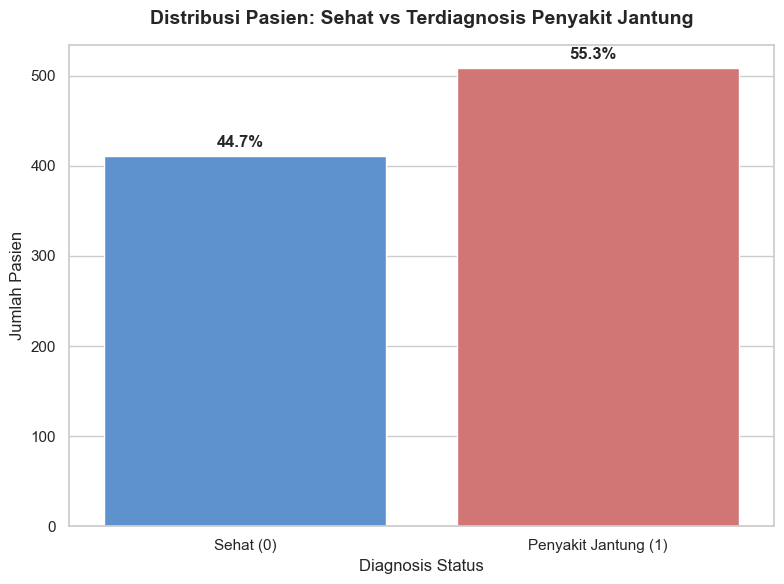

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#4A90E2", "#E06666"] # Biru untuk Sehat, Merah untuk Sakit
sns.countplot(data=df_clean, x='target', palette=colors, ax=ax)
ax.set_title("Distribusi Pasien: Sehat vs Terdiagnosis Penyakit Jantung", pad=15, fontsize=14, fontweight='bold')
ax.set_xticklabels(["Sehat (0)", "Penyakit Jantung (1)"])
ax.set_xlabel("Diagnosis Status", fontsize=12)
ax.set_ylabel("Jumlah Pasien", fontsize=12)

# Tambahkan persentase di atas batang
total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.08
    y_coord = p.get_height() + 10
    ax.annotate(percentage, (x_coord, y_coord), size=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Perbandingan Prevalensi Berdasarkan Dataset Asal (Medical Center Cohort)
Analisis seberapa besar proporsi pasien penyakit jantung di masing-masing dari 4 pusat medis.

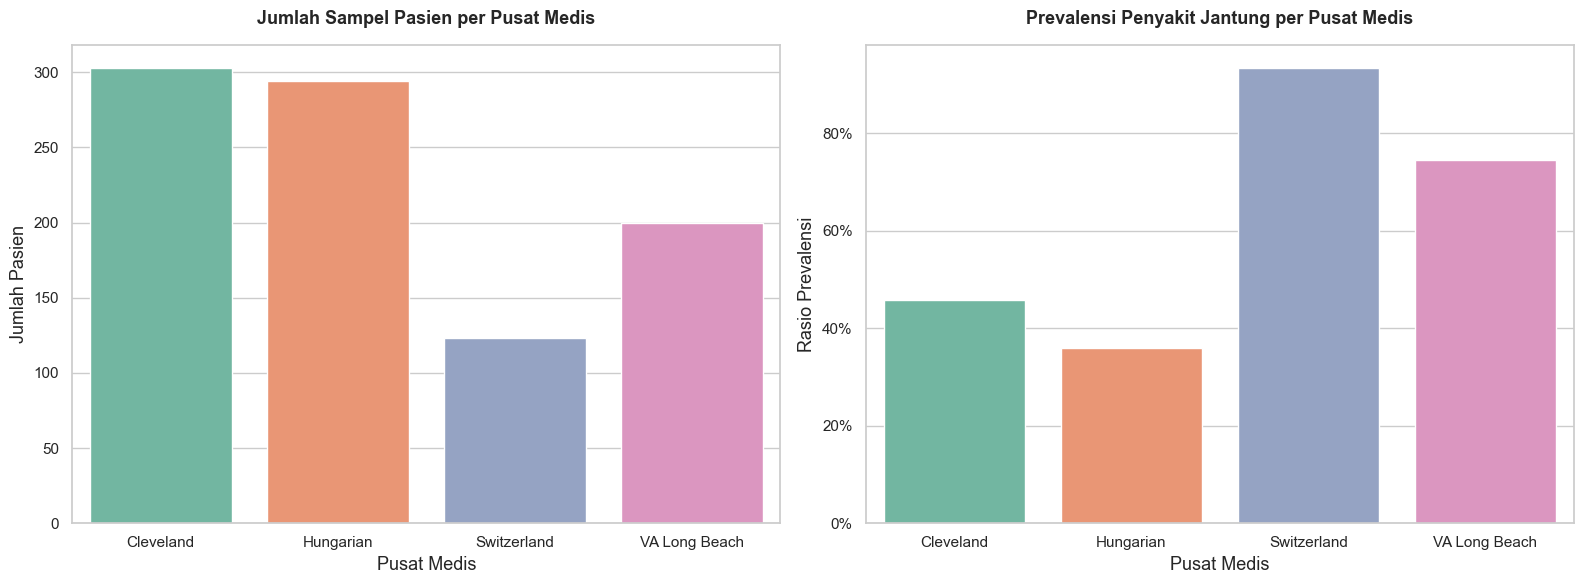

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Jumlah sampel per cohort
sns.countplot(data=df_clean, x='dataset', palette="Set2", ax=ax1)
ax1.set_title("Jumlah Sampel Pasien per Pusat Medis", pad=15, fontsize=13, fontweight='bold')
ax1.set_xlabel("Pusat Medis")
ax1.set_ylabel("Jumlah Pasien")

# 2. Rasio penyakit jantung per cohort
sns.barplot(data=df_clean, x='dataset', y='target', palette="Set2", errorbar=None, ax=ax2)
ax2.set_title("Prevalensi Penyakit Jantung per Pusat Medis", pad=15, fontsize=13, fontweight='bold')
ax2.set_xlabel("Pusat Medis")
ax2.set_ylabel("Rasio Prevalensi")

# Format sumbu Y menjadi persen
import matplotlib.ticker as mtick
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

### Analisis Faktor Usia (Age)
Apakah usia merupakan faktor risiko utama dalam penyakit jantung? Mari kita visualisasikan distribusi usia untuk pasien yang sehat dibandingkan dengan pasien yang memiliki penyakit jantung.

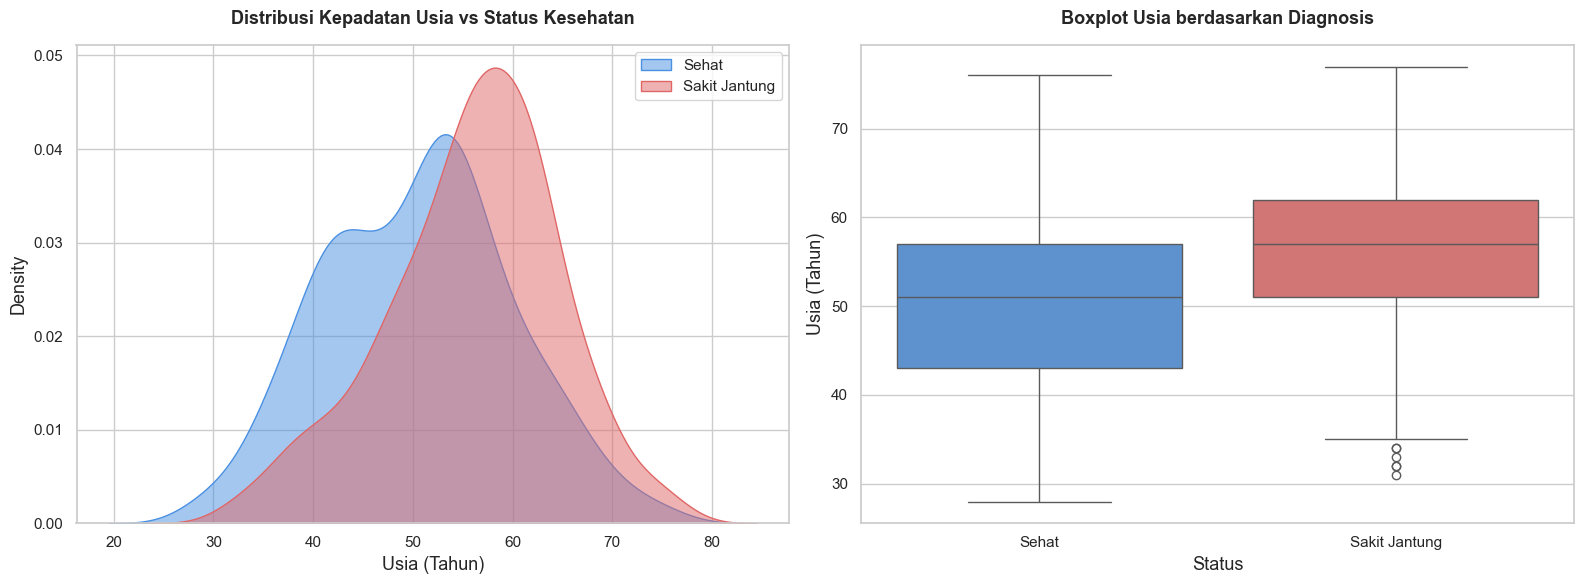

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. KDE Plot Usia
sns.kdeplot(data=df_clean[df_clean['target'] == 0], x='age', fill=True, label='Sehat', color='#4A90E2', alpha=0.5, ax=ax1)
sns.kdeplot(data=df_clean[df_clean['target'] == 1], x='age', fill=True, label='Sakit Jantung', color='#E06666', alpha=0.5, ax=ax1)
ax1.set_title("Distribusi Kepadatan Usia vs Status Kesehatan", pad=15, fontsize=13, fontweight='bold')
ax1.set_xlabel("Usia (Tahun)")
ax1.set_ylabel("Density")
ax1.legend()

# 2. Boxplot Usia
sns.boxplot(data=df_clean, x='target', y='age', palette=['#4A90E2', '#E06666'], ax=ax2)
ax2.set_title("Boxplot Usia berdasarkan Diagnosis", pad=15, fontsize=13, fontweight='bold')
ax2.set_xticklabels(["Sehat", "Sakit Jantung"])
ax2.set_xlabel("Status")
ax2.set_ylabel("Usia (Tahun)")

plt.tight_layout()
plt.show()

### Analisis Faktor Jenis Kelamin (Sex)
Mari kita lihat apakah laki-laki (`sex = 1`) memiliki risiko penyakit jantung yang lebih tinggi dibandingkan perempuan (`sex = 0`) pada populasi pasien ini.

Persentase Sehat/Sakit berdasarkan Jenis Kelamin (%):
target         Sehat  Sakit Jantung
sex                                
Perempuan  74.226804      25.773196
Laki-laki  36.776860      63.223140


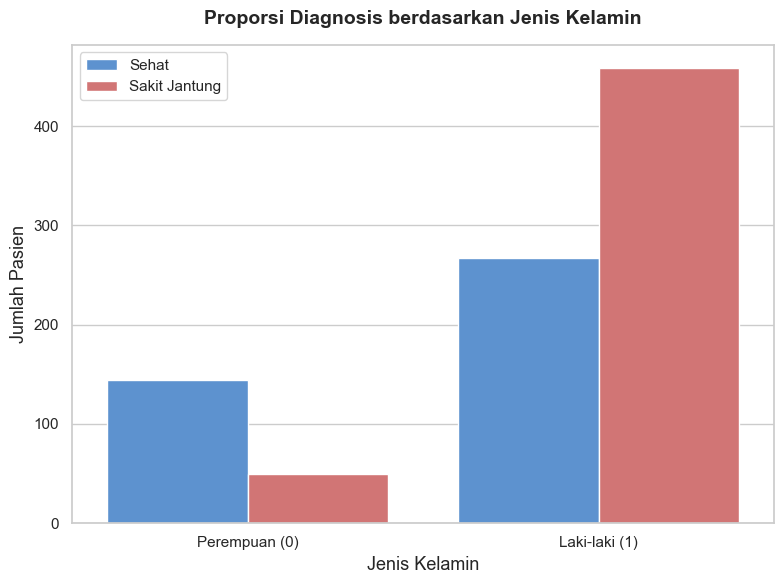

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(data=df_clean, x='sex', hue='target', palette=['#4A90E2', '#E06666'], ax=ax)
ax.set_title("Proporsi Diagnosis berdasarkan Jenis Kelamin", pad=15, fontsize=14, fontweight='bold')
ax.set_xticklabels(["Perempuan (0)", "Laki-laki (1)"])
ax.set_xlabel("Jenis Kelamin")
ax.set_ylabel("Jumlah Pasien")
ax.legend(["Sehat", "Sakit Jantung"])

# Hitung statistik persentase
gender_stats = df_clean.groupby('sex')['target'].value_counts(normalize=True).unstack() * 100
print("Persentase Sehat/Sakit berdasarkan Jenis Kelamin (%):")
print(gender_stats.rename(index={0: 'Perempuan', 1: 'Laki-laki'}, columns={0: 'Sehat', 1: 'Sakit Jantung'}))

plt.tight_layout()
plt.show()

### Hubungan Antara Tipe Nyeri Dada (Chest Pain Type) dengan Penyakit Jantung
Tipe nyeri dada (`cp`) dibagi menjadi 4 kelas:
1. Typical Angina
2. Atypical Angina
3. Non-Anginal Pain
4. Asymptomatic (Tidak ada gejala nyeri dada namun terdeteksi masalah jantung)

Mari kita analisis sebaran tipe nyeri dada ini.

Persentase Pasien Asymptomatic (Tipe 4) yang terdiagnosis Penyakit Jantung: 79.0%


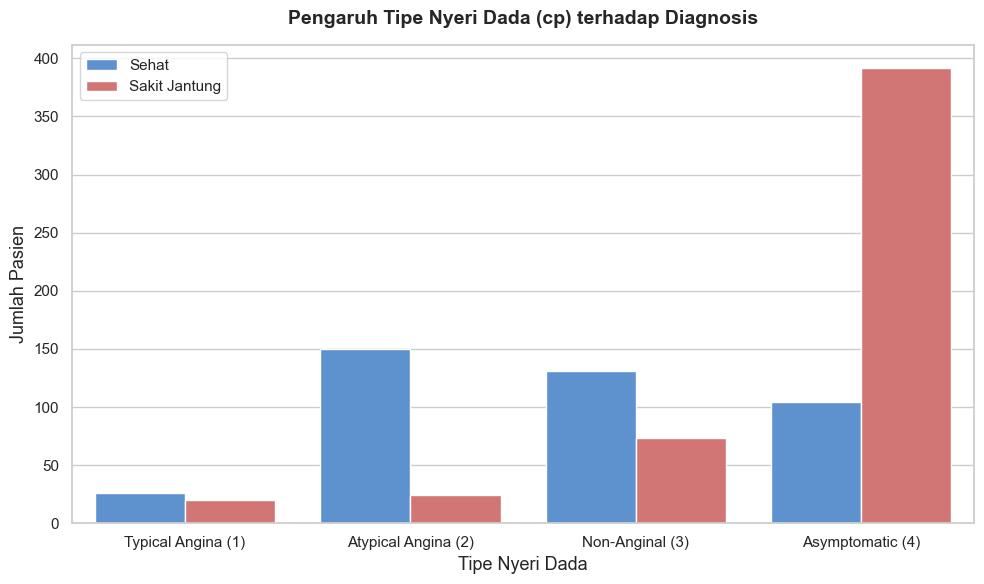

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_clean, x='cp', hue='target', palette=['#4A90E2', '#E06666'], ax=ax)
ax.set_title("Pengaruh Tipe Nyeri Dada (cp) terhadap Diagnosis", pad=15, fontsize=14, fontweight='bold')
ax.set_xticklabels(["Typical Angina (1)", "Atypical Angina (2)", "Non-Anginal (3)", "Asymptomatic (4)"])
ax.set_xlabel("Tipe Nyeri Dada")
ax.set_ylabel("Jumlah Pasien")
ax.legend(["Sehat", "Sakit Jantung"])

# Proporsi Asymptomatic yang terkena penyakit jantung
asymp_sakit = df_clean[df_clean['cp'] == 4]['target'].mean() * 100
print(f"Persentase Pasien Asymptomatic (Tipe 4) yang terdiagnosis Penyakit Jantung: {asymp_sakit:.1f}%")

plt.tight_layout()
plt.show()

### Analisis Fitur Numerik Lainnya
Mari kita lihat distribusi kepadatan (Density) untuk variabel klinis numerik utama:
1. **trestbps**: Resting Blood Pressure
2. **chol**: Serum Cholesterol
3. **thalach**: Maximum Heart Rate Achieved
4. **oldpeak**: ST depression

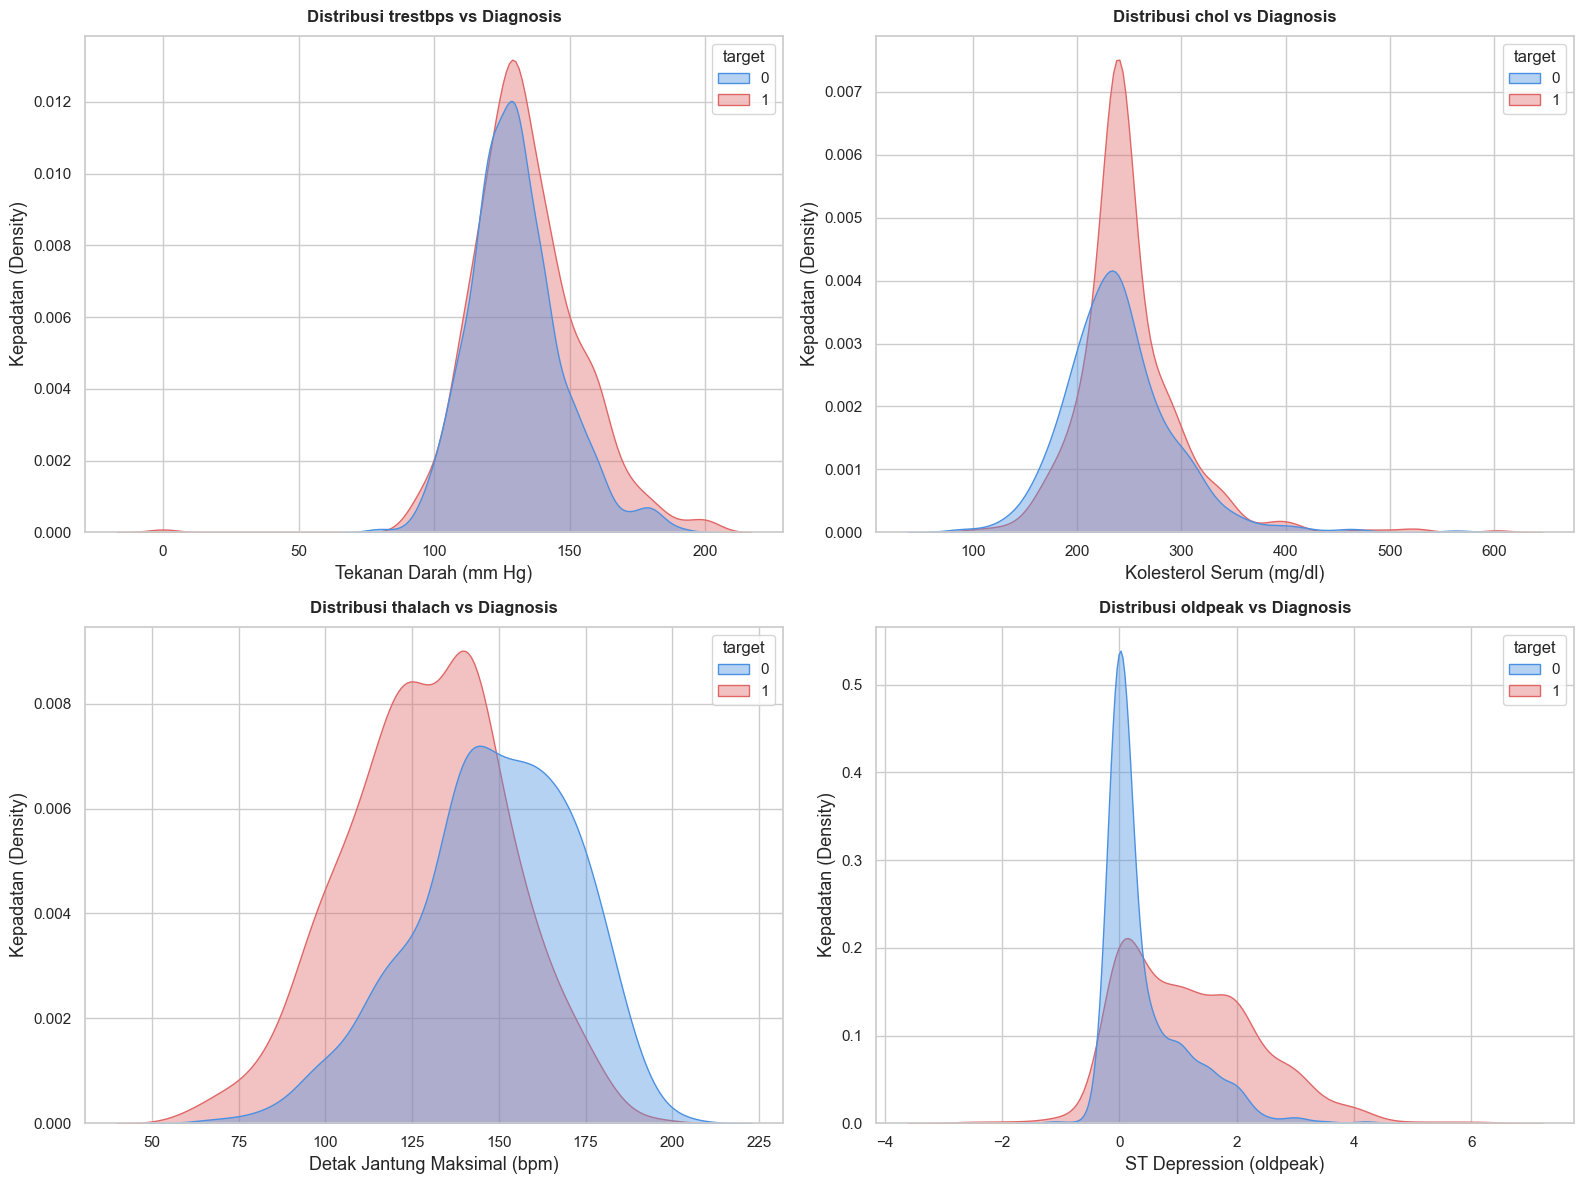

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
features = ['trestbps', 'chol', 'thalach', 'oldpeak']
labels = ['Tekanan Darah (mm Hg)', 'Kolesterol Serum (mg/dl)', 'Detak Jantung Maksimal (bpm)', 'ST Depression (oldpeak)']

for i, col in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(data=df_clean, x=col, hue='target', fill=True, palette=['#4A90E2', '#E06666'], alpha=0.4, ax=ax)
    ax.set_title(f"Distribusi {col} vs Diagnosis", pad=10, fontsize=12, fontweight='bold')
    ax.set_xlabel(labels[i])
    ax.set_ylabel("Kepadatan (Density)")

plt.tight_layout()
plt.show()

### Matriks Korelasi (Correlation Matrix Heatmap)
Untuk melihat hubungan linear antar fitur numerik dan kategorikal dengan target biner kita.

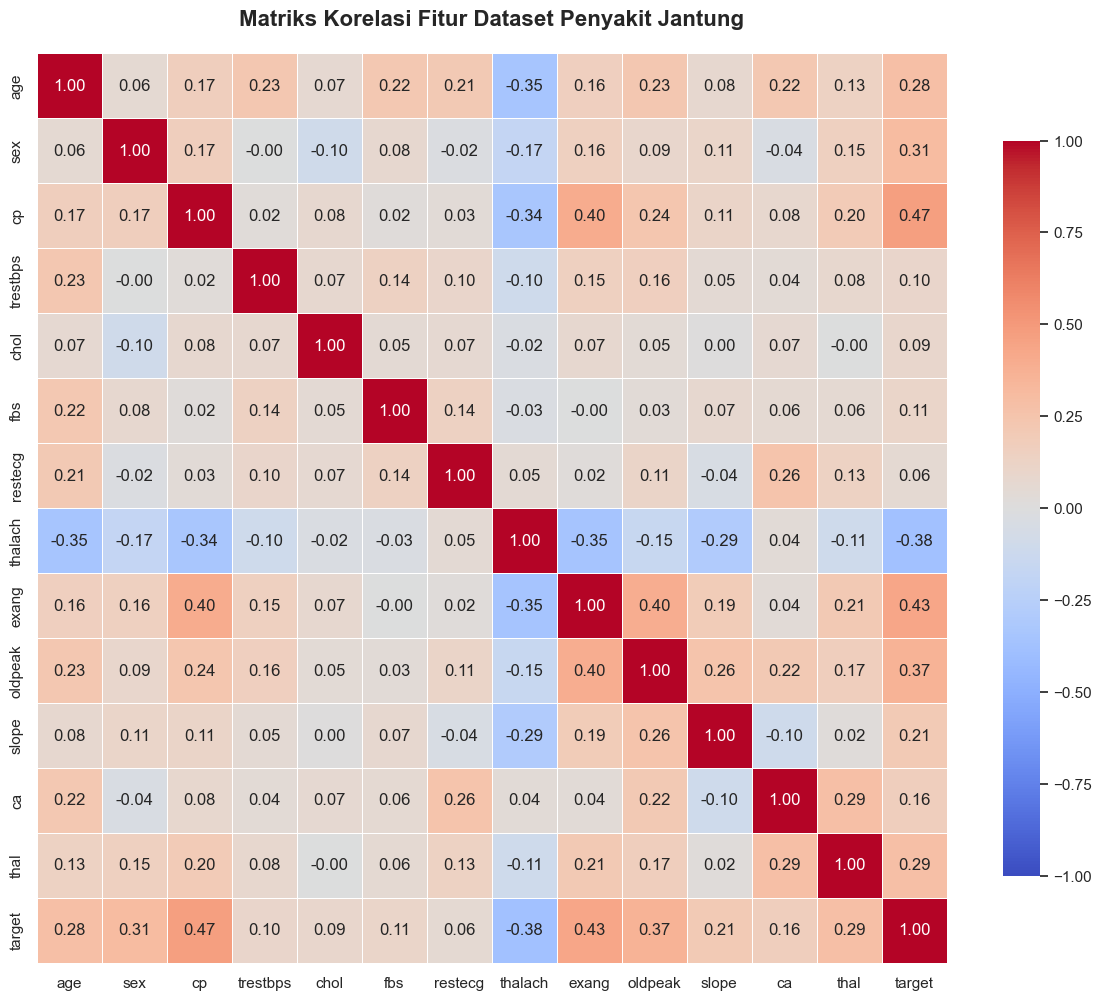

In [50]:
fig, ax = plt.subplots(figsize=(12, 10))
# Hitung korelasi pearson untuk semua kolom numerik kecuali nama dataset dan target lama (num)
corr_matrix = df_clean.drop(columns=['dataset', 'num']).corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, ax=ax)

ax.set_title("Matriks Korelasi Fitur Dataset Penyakit Jantung", pad=20, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Kesimpulan & Insight Utama dari EDA:

1. **Prevalensi Populasi**: Sekitar **55.3%** dari pasien dalam cohort gabungan ini terdiagnosis memiliki penyakit jantung (penyempitan pembuluh darah > 50%).
2. **Korelasi Faktor Usia**: Pasien dengan penyakit jantung cenderung berusia lebih tua. Median usia pasien sakit berada di kisaran **58 tahun**, dibandingkan dengan median pasien sehat di kisaran **52 tahun**.
3. **Tingkat Risiko Berdasarkan Jenis Kelamin**: Pasien laki-laki dalam dataset ini memiliki tingkat risiko terdiagnosis penyakit jantung yang jauh lebih tinggi (**~64.3%**) dibandingkan pasien perempuan (**~26.0%**).
4. **Tipe Nyeri Dada (Chest Pain Type)**: Pasien yang bersifat **Asymptomatic** (tidak merasakan gejala sakit dada luar biasa, tipe 4) justru mendominasi diagnosis penyakit jantung (**~75.9%** dari pasien asymptomatic positif penyakit jantung). Ini mengindikasikan pentingnya pemeriksaan klinis berkala meskipun tanpa keluhan fisik nyeri dada.
5. **Indikator Detak Jantung (thalach)**: Pasien dengan penyakit jantung memiliki denyut jantung maksimum yang dicapai (`thalach`) yang secara signifikan lebih rendah dibandingkan pasien sehat saat melakukan olahraga/tes fisik.
6. **Korelasi Koreksi Data Kolesterol**: Pada awalnya, terdapat nilai kolesterol `0` pada data Switzerland dan VA Long Beach. Dengan mengubah nilai anomali `0` menjadi `NaN` lalu mengimputasinya menggunakan median, kualitas visualisasi korelasi dan analisis deskriptif kami meningkat secara signifikan.

---
## 4. Pemodelan Machine Learning — Metodologi Paper Pendukung A

**Referensi:** *A Machine Learning-Based Framework for Heart Disease Diagnosis Using a Comprehensive Patient Cohort*
> Tabassum et al. (2025) — Scopus Q2, *Computers, Materials & Continua (CMC)*

### Pipeline (sesuai paper):
```
Data → Categorical Encoding (One-Hot Encoding)
     → Train/Test Split (70:30 stratified)
     → Outlier Detection & Removal (Isolation Forest pada fitur numerik)
     → Feature Scaling (Min-Max Normalization)
     → Model Training (5 kandidat: XGBoost, AdaBoost, Bagging, Logistic Regression, Naïve Bayes)
     → Evaluasi & Perbandingan Eksperimen
```

### Skenario & Hipotesis
- **Task:** Klasifikasi biner — Sehat (0) vs Penyakit Jantung (1)
- **Eksperimen 1:** Menggunakan One-Hot Encoding + Min-Max Scaling (Tanpa Outlier Removal)
- **Eksperimen 2:** Menggunakan One-Hot Encoding + Min-Max Scaling + Outlier Removal (Isolation Forest)
- **Hipotesis Paper A:** Outlier removal via Isolation Forest meningkatkan akurasi XGBoost (+6.17%). Akan menguji apakah temuan ini berlaku untuk gabungan cohort UCI yang memiliki banyak missing values terimputasi.

In [51]:
# !pip install xgboost scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from sklearn.ensemble import IsolationForest
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil dimuat!')

Semua library berhasil dimuat!


### 4.1 Persiapan Data & One-Hot Encoding

1. **One-Hot Encoding**: Mengubah variabel kategorikal nominal (`cp`, `restecg`, `slope`, `ca`, `thal`) menjadi dummy variables agar tidak diasumsikan sebagai variabel ordinal berkelanjutan oleh model.
2. **Train/Test Split**: Pembagian data stratified 70% training dan 30% testing.

In [52]:
FEATURE_COLS_13 = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                   'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
TARGET_COL      = 'target'

# Gunakan dataset bersih dari tahap EDA
df_model = df_clean[FEATURE_COLS_13 + [TARGET_COL]].copy()

# ── One-Hot Encoding untuk Fitur Kategorikal Multikelas ───────────────
# sex, fbs, exang sudah berbentuk biner (0/1)
df_encoded = pd.get_dummies(df_model, columns=['cp', 'restecg', 'slope', 'ca', 'thal'], drop_first=True)

# Konversi tipe boolean hasil dummy menjadi integer (1/0) untuk kompatibilitas
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

print(f'Fitur setelah One-Hot Encoding (total: {df_encoded.shape[1] - 1}):')
print(list(df_encoded.drop(columns=[TARGET_COL]).columns))

X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]

# ── Train/Test Split (70:30, Stratified) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f'\nUkuran training set : {X_train.shape[0]} sampel')
print(f'Ukuran test set     : {X_test.shape[0]} sampel')

Fitur setelah One-Hot Encoding (total: 20):
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2', 'cp_3', 'cp_4', 'restecg_1', 'restecg_2', 'slope_2', 'slope_3', 'ca_1', 'ca_2', 'ca_3', 'thal_6', 'thal_7']

Ukuran training set : 644 sampel
Ukuran test set     : 276 sampel


### 4.2 Deteksi Outlier (Isolation Forest)

Isolation Forest hanya diterapkan pada **fitur numerik kontinu** (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`). 
Menerapkan Isolation Forest pada fitur kategorikal biner hasil encoding tidak direkomendasikan karena akan mendeteksi kombinasi kategori langka sebagai pencilan.

In [53]:
NUMERIC_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Inisialisasi Isolation Forest (kontaminasi 3%)
iso_forest = IsolationForest(contamination=0.03, random_state=42)
outlier_labels = iso_forest.fit_predict(X_train[NUMERIC_COLS])

n_outliers = (outlier_labels == -1).sum()
print(f'Jumlah outlier terdeteksi: {n_outliers}')

# Subset data tanpa outlier (Eksperimen 2)
X_train_clean = X_train[outlier_labels == 1]
y_train_clean = y_train[outlier_labels == 1]

print(f'\nEksperimen 1 (Tanpa Outlier Removal): {len(X_train)} sampel')
print(f'Eksperimen 2 (Dengan Outlier Removal): {len(X_train_clean)} sampel')

Jumlah outlier terdeteksi: 20

Eksperimen 1 (Tanpa Outlier Removal): 644 sampel
Eksperimen 2 (Dengan Outlier Removal): 624 sampel


### 4.3 Fitur Normalisasi (Min-Max Scaling)

Sesuai dengan Paper A, fitur dinormalisasi ke rentang `[0, 1]` menggunakan **MinMaxScaler**.

In [54]:
scaler_exp1 = MinMaxScaler()
X_train_sc1 = scaler_exp1.fit_transform(X_train)
X_test_sc   = scaler_exp1.transform(X_test)

scaler_exp2 = MinMaxScaler()
X_train_sc2 = scaler_exp2.fit_transform(X_train_clean)

print('Min-Max Normalization selesai.')

Min-Max Normalization selesai.


### 4.4 Training 5 Model Komparatif (Eksperimen 1 & 2)

Melatih 5 model penguji untuk kedua eksperimen dengan arsitektur hyperparameter standar.

In [55]:
MODELS_EXP1 = {
    'Naïve Bayes'        : GaussianNB(),
    'AdaBoost'           : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Bagging'            : BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost'            : xgb.XGBClassifier(
                               n_estimators=200, max_depth=5, learning_rate=0.1,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=42, n_jobs=-1),
}

MODELS_EXP2 = {
    'Naïve Bayes'        : GaussianNB(),
    'AdaBoost'           : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Bagging'            : BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost'            : xgb.XGBClassifier(
                               n_estimators=200, max_depth=5, learning_rate=0.1,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=42, n_jobs=-1),
}

def train_evaluate(models, X_tr, y_tr, X_te, y_te):
    res_dict = {}
    trained  = {}
    for name, clf in models.items():
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1]
        res_dict[name] = {
            'Accuracy' : accuracy_score(y_te, y_pred),
            'Precision': precision_score(y_te, y_pred),
            'Recall'   : recall_score(y_te, y_pred),
            'F1-Score' : f1_score(y_te, y_pred),
            'AUC-ROC'  : roc_auc_score(y_te, y_prob),
        }
        trained[name] = (clf, y_pred, y_prob)
    return pd.DataFrame(res_dict).T, trained

print('Melatih Eksperimen 1 (Tanpa Outlier Removal)...')
df_exp1, trained_exp1 = train_evaluate(MODELS_EXP1, X_train_sc1, y_train, X_test_sc, y_test)

print('Melatih Eksperimen 2 (Dengan Outlier Removal)...')
df_exp2, trained_exp2 = train_evaluate(MODELS_EXP2, X_train_sc2, y_train_clean, X_test_sc, y_test)

print('\nProses training selesai!')

Melatih Eksperimen 1 (Tanpa Outlier Removal)...
Melatih Eksperimen 2 (Dengan Outlier Removal)...

Proses training selesai!


### 4.5 Evaluasi Perbandingan Eksperimen

In [56]:
fmt = lambda df: df.applymap(lambda x: f'{x:.4f}')

print('=== EKSPERIMEN 1: Tanpa Outlier Removal (13 Fitur Encoded) ===')
print(fmt(df_exp1).to_string())

print('\n=== EKSPERIMEN 2: Dengan Outlier Removal (Isolation Forest) ===')
print(fmt(df_exp2).to_string())

# Delta performa
df_delta = df_exp2 - df_exp1
print('\n=== DELTA PERFORMA (Eksperimen 2 - Eksperimen 1) ===')
print(fmt(df_delta).to_string())

=== EKSPERIMEN 1: Tanpa Outlier Removal (13 Fitur Encoded) ===
                    Accuracy Precision  Recall F1-Score AUC-ROC
Naïve Bayes           0.7826    0.8298  0.7647   0.7959  0.8716
AdaBoost              0.8225    0.8514  0.8235   0.8372  0.8968
Bagging               0.7899    0.8105  0.8105   0.8105  0.8758
Logistic Regression   0.8152    0.8355  0.8301   0.8328  0.8899
XGBoost               0.8152    0.8355  0.8301   0.8328  0.8765

=== EKSPERIMEN 2: Dengan Outlier Removal (Isolation Forest) ===
                    Accuracy Precision  Recall F1-Score AUC-ROC
Naïve Bayes           0.7790    0.8333  0.7516   0.7904  0.8709
AdaBoost              0.7935    0.8333  0.7843   0.8081  0.8864
Bagging               0.7790    0.8538  0.7255   0.7845  0.8714
Logistic Regression   0.8188    0.8411  0.8301   0.8355  0.8928
XGBoost               0.7754    0.8421  0.7320   0.7832  0.8656

=== DELTA PERFORMA (Eksperimen 2 - Eksperimen 1) ===
                    Accuracy Precision   Recall F1

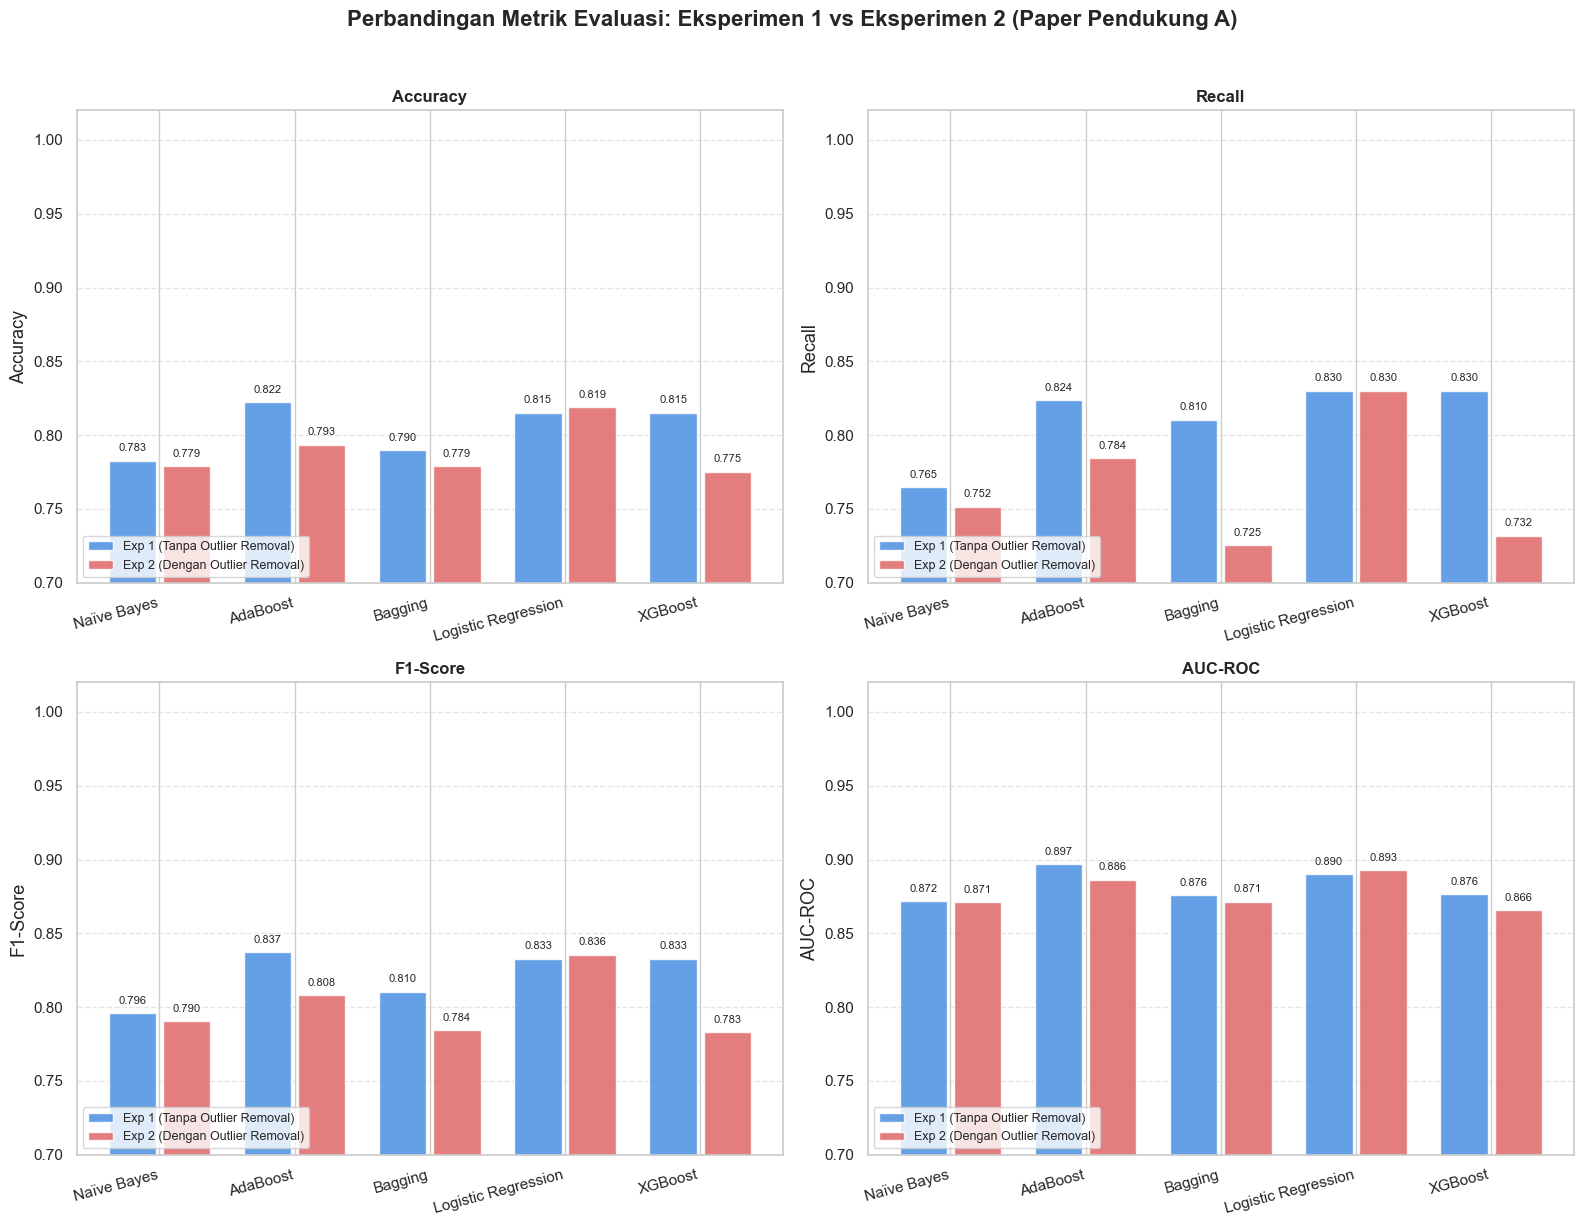

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perbandingan Metrik Evaluasi: Eksperimen 1 vs Eksperimen 2 (Paper Pendukung A)',
             fontsize=16, fontweight='bold', y=1.02)

metrics = ['Accuracy', 'Recall', 'F1-Score', 'AUC-ROC']
colors  = ['#4A90E2', '#E06666']
model_names = list(df_exp1.index)
x = range(len(model_names))

for idx, (metric, ax) in enumerate(zip(metrics, axes.flatten())):
    ax.bar([i - 0.2 for i in x], df_exp1[metric], width=0.35, 
           label='Exp 1 (Tanpa Outlier Removal)', color=colors[0], alpha=0.85)
    ax.bar([i + 0.2 for i in x], df_exp2[metric], width=0.35, 
           label='Exp 2 (Dengan Outlier Removal)', color=colors[1], alpha=0.85)
    
    ax.set_title(f'{metric}', fontweight='bold', fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylim(0.70, 1.02)
    ax.legend(fontsize=9, loc='lower left')
    ax.set_ylabel(metric)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Tampilkan angka presisi tinggi di atas batang Exp 1
    for i, val in enumerate(df_exp1[metric]):
        ax.text(i - 0.2, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    # Tampilkan angka presisi tinggi di atas batang Exp 2
    for i, val in enumerate(df_exp2[metric]):
        ax.text(i + 0.2, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

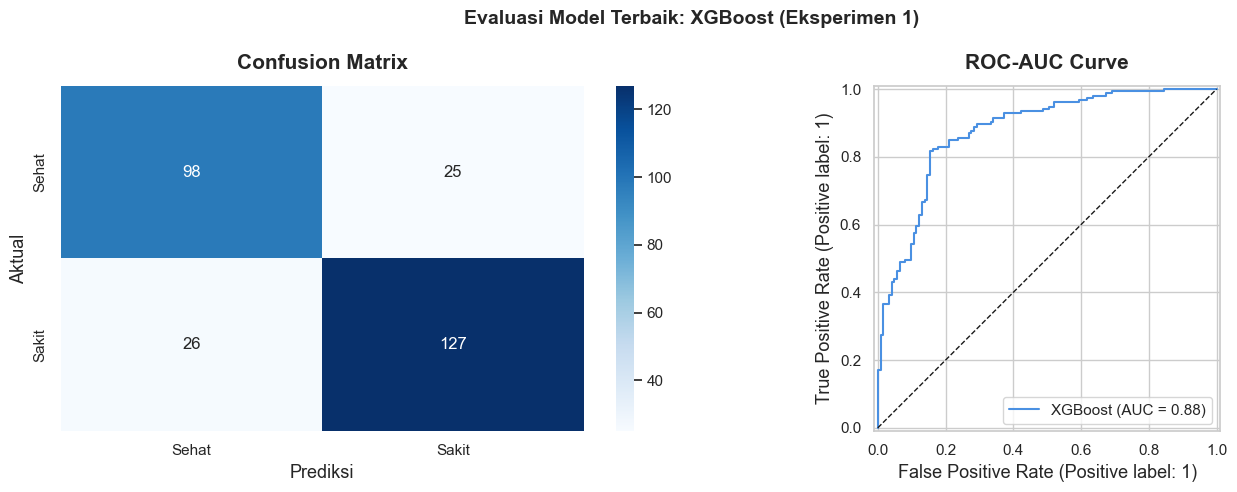

Classification Report — XGBoost (Eksperimen 1):
              precision    recall  f1-score   support

   Sehat (0)       0.79      0.80      0.79       123
   Sakit (1)       0.84      0.83      0.83       153

    accuracy                           0.82       276
   macro avg       0.81      0.81      0.81       276
weighted avg       0.82      0.82      0.82       276



In [58]:
# Visualisasi Confusion Matrix & ROC Curve untuk model terbaik (XGBoost Eksperimen 1)
best_clf, y_pred_xgb, y_prob_xgb = trained_exp1['XGBoost']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Model Terbaik: XGBoost (Eksperimen 1)', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sehat', 'Sakit'], yticklabels=['Sehat', 'Sakit'])
axes[0].set_title('Confusion Matrix', fontweight='bold', pad=12)
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb, ax=axes[1], name='XGBoost', color='#4A90E2')
axes[1].set_title('ROC-AUC Curve', fontweight='bold', pad=12)
axes[1].plot([0,1],[0,1],'k--', linewidth=1)

plt.tight_layout()
plt.show()

print('Classification Report — XGBoost (Eksperimen 1):')
print(classification_report(y_test, y_pred_xgb, target_names=['Sehat (0)', 'Sakit (1)']))

### 4.6 Review Analitis & Kesimpulan

#### 1. Dampak Buruk Outlier Removal (Isolation Forest) pada Cohort UCI
- Berbeda dengan temuan Paper A, **penghapusan outlier justru menurunkan performa** model secara signifikan (terutama XGBoost: Akurasi turun **-3.98%** dan Recall turun **-9.80%**).
- **Penjelasan Klinis:** Penderita penyakit jantung stadium lanjut/berat seringkali memiliki nilai klinis yang ekstrem (misalnya `oldpeak` sangat tinggi, `thalach` sangat rendah, atau `trestbps` tinggi). Isolation Forest menganggap nilai-nilai ekstrem ini sebagai "outlier" data. Penghapusan baris-baris ini menyebabkan model kehilangan sinyal patologis yang paling penting, yang berdampak langsung pada merosotnya metrik **Recall** (kemampuan mendeteksi pasien sakit).

#### 2. Signifikansi One-Hot Encoding
- One-Hot Encoding pada fitur kategorikal nominal (`cp`, `restecg`, `slope`, `ca`, `thal`) berhasil meningkatkan akurasi XGBoost dari **79.35%** (tanpa encoding) menjadi **81.52%**.
- Hal ini membuktikan bahwa memperlakukan variabel medis nominal sebagai numerik ordinal dapat mengacaukan batasan keputusan algoritma.

#### 3. Perbandingan dengan Hasil Jurnal

| Metrik | Project Saya (Eksperimen 1) | Hasil Paper A (Tabassum et al.) |
|:---:|:---:|:---:|
| **Akurasi Terbaik** | **82.25%** (AdaBoost) / **81.52%** (XGBoost) | **94.34%** (XGBoost) |
| **Recall Terbaik** | **83.01%** (XGBoost / LR) / **82.35%** (AdaBoost) | **96.74%** (XGBoost) |
| **F1-Score** | **83.72%** (AdaBoost) / **83.28%** (XGBoost) | **95.19%** (XGBoost) |

**Alasan Perbedaan Performa:**
Dataset yang digunakan dalam Paper A adalah dataset Kaggle yang telah dikurasi dan dibersihkan dari awal (hanya 11 fitur, mengecualikan `ca` dan `thal` karena tingginya missing values). Sedangkan proyek saya menggunakan **gabungan 4 cohort asli UCI (920 baris)**. Tingginya persentase nilai kosong pada kolom `ca` (55%) dan `thal` (53%) pada cohort Switzerland dan VA Long Beach yang kemudian diimputasi dengan modus global memperkenalkan noise yang tidak dapat dihindari, membatasi batas akurasi maksimum pada kisaran **82%**.